# 4 Self-attention

This notebook introduces sequence embeddings, the attention calculation, padding masks and positional information. We will inspect a small attention matrix and build a transformer encoder block. The examples in this notebook are hand-written or randomly initialized; the next notebook uses a pretrained protein model.

In [1]:
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

seed_everything(42)

## 4.1 Tokens are discrete symbols; embeddings are numerical representations
For this toy example, each DNA base is one token. Integer token IDs are lookup addresses, not quantities. An embedding table maps each address to a vector. Its entries are parameters learned during training.

The table below is randomly initialized. Nearby vectors therefore do **not** yet imply biological similarity. A contextual representation will later depend on the other tokens in the sequence.

In [2]:
import math, numpy as np, pandas as pd, torch
from torch import nn
import matplotlib.pyplot as plt
token_ids = {base: i for i, base in enumerate("ACGT")}
seed_everything(42)
embedding = nn.Embedding(4, 3)
display(pd.DataFrame(embedding.weight.detach().numpy(), index=list("ACGT"), columns=["feature 1", "feature 2", "feature 3"]))
sequence = "ACGA"
ids = torch.tensor([token_ids[base] for base in sequence])
print("IDs:", ids.tolist())
print("Embedding shape:", embedding(ids).shape)

,feature 1,feature 2,feature 3
A,0.336690,0.128809,0.234462
C,0.230333,-1.122856,-0.186328
G,2.208201,-0.637997,0.461657
T,0.267351,0.534905,0.809357


IDs: [0, 1, 2, 0]
Embedding shape: torch.Size([4, 3])


*Assignment: Same token, same initial vector*

In `ACGA`, do both A positions get the same lookup embedding? Must their representations still be identical after position information and self-attention?

*Write your answer here.*

## 4.2 Attention is a weighted combination
Suppose we combine two vectors with weights 0.75 and 0.25. The output lies closer to the first vector. Attention computes such weights from the current inputs instead of fixing them in advance.

The words **query**, **key** and **value** describe roles: a query is compared with keys to decide how to combine values. They are numerical projections, not literal questions or database keys.

In [3]:
values = torch.tensor([[2., 0.], [0., 4.]])
weights = torch.tensor([0.75, 0.25])
print("Weighted combination:", weights @ values)

Weighted combination: tensor([1.5000, 1.0000])


## 4.3 Compute one attention head
Here Q, K and V are small hand-written matrices chosen only to make the calculation inspectable. In a model, learned linear maps produce them from token representations.

1. Compare every query with every key using a dot product.
2. Divide by the square root of the key dimension to control the score scale.
3. Apply softmax across each row to get weights that sum to 1.
4. Use those weights to combine the value vectors.

Rows are **positions receiving information**; columns are **positions supplying it**. This example is bidirectional, with no causal mask.

In [4]:
Q = torch.tensor([[1., 0.], [0., 1.], [1., 1.], [-1., 0.]])
K = Q.clone()
V = torch.tensor([[1., 0.], [0., 1.], [2., 2.], [-1., 1.]])
scores = Q @ K.T / math.sqrt(K.shape[-1])
attention_weights = torch.softmax(scores, dim=-1)
context = attention_weights @ V
positions = [f"{i}:{base}" for i, base in enumerate("ACGT")]
display(pd.DataFrame(attention_weights.numpy(), index=positions, columns=positions).round(3))
print("Row sums:", attention_weights.sum(-1))
print("Context vectors:", context)

,0:A,1:C,2:G,3:T
0:A,0.365,0.180,0.365,0.089
1:C,0.165,0.335,0.335,0.165
2:G,0.234,0.234,0.475,0.057
3:T,0.123,0.249,0.123,0.505


Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000])
Context vectors: tensor([[ 1.0076,  1.0000],
        [ 0.6698,  1.1698],
        [ 1.1269,  1.2407],
        [-0.1367,  1.0000]])


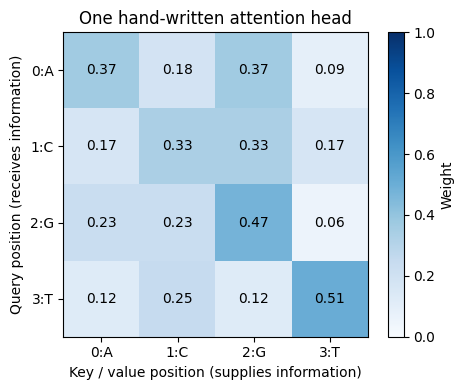

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attention_weights.numpy(), vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(4), positions); ax.set_yticks(range(4), positions)
ax.set(xlabel="Key / value position (supplies information)", ylabel="Query position (receives information)",
       title="One hand-written attention head")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{attention_weights[i,j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Weight")
plt.tight_layout(); plt.show()

*Assignment: Follow one row*

Which position contributes most to query position 0? Reconstruct its context vector as a weighted sum. Does a large attention weight prove physical interaction between bases?

In [6]:
query_position = 0
print("Largest contributor:", int(attention_weights[query_position].argmax()))
print("Context:", attention_weights[query_position] @ V)

Largest contributor: 0
Context: tensor([1.0076, 1.0000])


*Write your answer here.*

## 4.4 Padding is not a biological symbol
Variable-length sequences are padded to form a rectangular batch. Reserve a separate padding ID: **do not reuse A or another real token**.

Mask padded key positions before softmax so real positions cannot read them. When pooling to a sequence vector, also exclude padded output positions. Those output vectors need not themselves be zero.

In [7]:
valid_positions = torch.tensor([True, True, True, False])  # Last position is padding in this demonstration.
masked_scores = scores.masked_fill(~valid_positions.unsqueeze(0), float("-inf"))
masked_attention = torch.softmax(masked_scores, dim=-1)
print("Weight given to the padded key:", masked_attention[:, -1])
assert torch.all(masked_attention[:, -1] == 0)

Weight given to the padded key: tensor([0., 0., 0., 0.])


*Assignment: Diagnose the padding bug*

If A has ID 0 and padding also has ID 0, can an embedding lookup distinguish a real A from padding? What two operations must ignore padding?

*Write your answer here.*

## 4.5 Assemble a transformer encoder block
A block combines **multi-head self-attention**, a **feed-forward network**, **residual additions** and **layer normalization**. Heads can learn different projections. A residual addition preserves a path for the input representation; layer normalization stabilizes feature scales within each token.

Sequence IDs → token embeddings + position embeddings → encoder block → masked mean → sequence vector.

The following model is randomly initialized and untrained. We inspect shapes and symmetries; it makes no biological predictions. Dropout is zero to make comparisons deterministic.

In [8]:
PAD_ID = 4

class TinyEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.tokens = nn.Embedding(5, 8, padding_idx=PAD_ID)
        self.positions = nn.Embedding(64, 8)
        self.block = nn.TransformerEncoderLayer(d_model=8, nhead=2, dim_feedforward=16,
                                                dropout=0.0, batch_first=True)

    def forward(self, ids, use_positions=True):
        valid = ids.ne(PAD_ID)
        x = self.tokens(ids)
        if use_positions:
            x = x + self.positions(torch.arange(ids.shape[1], device=ids.device))[None, :, :]
        # PyTorch's key-padding mask uses True for positions to IGNORE.
        x = self.block(x, src_key_padding_mask=~valid)
        return (x * valid.unsqueeze(-1)).sum(1) / valid.sum(1, keepdim=True)

seed_everything(42)
encoder = TinyEncoder().eval()
batch = torch.tensor([[0, 1, 2, 3, PAD_ID, PAD_ID], [0, 1, 2, 3, 0, 0]])
with torch.no_grad():
    vectors = encoder(batch)
    alone = encoder(batch[:1, :4])
print("Two sequences, one vector each:", vectors.shape)
print("Same sequence alone or padded in a batch:", torch.allclose(alone[0], vectors[0], atol=1e-5))
assert torch.allclose(alone[0], vectors[0], atol=1e-5)

Two sequences, one vector each: torch.Size([2, 8])
Same sequence alone or padded in a batch: True


## 4.6 Why position information matters
Without positional information, this encoder is permutation-equivariant: shuffling tokens shuffles token outputs. After mean pooling, its sequence vector is invariant to order. `ACGT` and `TGCA` therefore cannot be distinguished by this pooled architecture unless we provide position information or another source of order.

*Assignment: Remove position information*

Compare the pooled vectors for `ACGT` and `TGCA` with positions disabled, then enabled. Why is order needed for biological sequence tasks?

In [9]:
pair = torch.tensor([[0, 1, 2, 3], [3, 2, 1, 0]])
with torch.no_grad():
    pooled = encoder(pair, use_positions=False)  # Change to True.
print("Largest difference:", (pooled[0] - pooled[1]).abs().max().item())

Largest difference: 1.1920928955078125e-07


*Write your answer here.*

*Optional assignment: Causal versus bidirectional attention*

For next-token generation, which positions must a query be prevented from reading? Why does our protein encoder practical not use that mask?

In [ ]:
causal_scores = scores.clone()  # Add an upper-triangular mask if exploring this challenge.
print(torch.softmax(causal_scores, dim=-1))

*Write your answer here.*